# Wafer reference-localization model -- cleaned pipeline

**What changed vs. your last notebook:**
- Removed the duplicate/broken checkpoint-recovery cells (the ones hitting `IsADirectoryError` / `UnpicklingError`).
- Removed the duplicate `WaferMatchNetV2` fine-tune cell (redundant with the base model, which already has the projection head built in).
- Removed the unused legacy `ConvBlock` (BatchNorm) class -- only `ConvBlockGN` is actually used.
- Restored the intended order: **Config -> Dataset -> Split -> Model -> Resume checkpoint -> Train -> Evaluate -> Graphs -> Heatmaps -> Test bench -> Fine-tune -> Quick save**.
- New **CELL 5** loads a checkpoint if you point it at one (fixed with `weights_only=False`), and deliberately does **not** restore the optimizer state when resuming, since your `checkpoint_emergency.pt` had already plateaued around 200px -- a fresh optimizer + warmup gives it a real chance to break past that instead of continuing to idle.

**Before running:** in Notebook Settings (right sidebar) turn on **GPU** and **Internet** and re-attach your two wafer datasets. If you want to resume `checkpoint_emergency.pt`, upload it as a **Dataset** (not a Model, to avoid the extra nested folder) via Add Input, then update `RESUME_CHECKPOINT_PATH` in CELL 5 to match.


In [1]:
# =============================================================================
# Copy Checkpoint from Input to Working Directory
# =============================================================================
# Run this cell if you want to:
# 1. Load an old checkpoint from /kaggle/input/...
# 2. Copy it to /kaggle/working/... so you can resume from it
# 3. Continue training and save new progress to /kaggle/working/...
# =============================================================================

import shutil
import os

INPUT_CHECKPOINT = "/kaggle/input/datasets/bolt09/checkpoint-v1/checkpoint_emergency.pt"
WORKING_CHECKPOINT = "/kaggle/working/checkpoint_manual_save.pt"

if os.path.exists(INPUT_CHECKPOINT):
    print(f"Found checkpoint at: {INPUT_CHECKPOINT}")
    print(f"Copying to: {WORKING_CHECKPOINT}")
    shutil.copy(INPUT_CHECKPOINT, WORKING_CHECKPOINT)
    print(f"✓ Copy complete!")
    print(f"  File size: {os.path.getsize(WORKING_CHECKPOINT) / (1024**2):.2f} MB")
else:
    print(f"✗ No checkpoint found at {INPUT_CHECKPOINT}")
    print(f"  Skipping copy. Will start fresh instead.")

# Verify it's there
if os.path.exists(WORKING_CHECKPOINT):
    print(f"\n✓ Checkpoint is now available at /kaggle/working/ for resuming")
else:
    print(f"\n✗ Checkpoint copy failed")

Found checkpoint at: /kaggle/input/datasets/bolt09/checkpoint-v1/checkpoint_emergency.pt
Copying to: /kaggle/working/checkpoint_manual_save.pt
✓ Copy complete!
  File size: 2.32 MB

✓ Checkpoint is now available at /kaggle/working/ for resuming


In [27]:
# =============================================================================
# CELL 1 -- Setup & Config
# =============================================================================
# =============================================================================
import os, random, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ---- EDIT THESE to match your dataset slugs in the "Add Input" panel ----
MIXED_ROOT = "/kaggle/input/datasets/bolt09/final-mix"
MESH_ROOT  = "/kaggle/input/datasets/bolt09/final-mesh"

# ---- Resolution config -----------------------------------------------------
ORIG_SIZE   = 1000
SEARCH_SIZE = 1000
REF_SIZE    = 100     # = SEARCH_SIZE * 0.1, matches the generator's ref_zoom=10

# ---- Pretrained backbone -----------------------------------------------------
# Uses ImageNet-pretrained ResNet18's stem+layer1 (downsamples /4, same as our
# from-scratch encoder did) as a better-initialized feature extractor. This
# needs internet access to download the weights the first time:
#   Notebook settings (right sidebar) -> Internet -> On
# If it's off, or the download fails for any reason, this automatically falls
# back to the from-scratch encoder so the notebook still runs end to end.
USE_PRETRAINED = True

BATCH_SIZE = 6
EPOCHS = 150               # long run -- early stopping below will cut it short if it plateaus
EARLY_STOP_PATIENCE = 12  # stop if val_px_err hasn't improved in this many epochs
BACKBONE_LR = 4e-5   # cautious LR for the (possibly pretrained) encoder
HEAD_LR = 3e-4        # faster LR for the always-from-scratch projection head
WARMUP_EPOCHS = 15     # linear LR ramp-up, helps avoid early destabilizing updates

HEATMAP_SIGMA = 0.9
COORD_LOSS_WEIGHT = 5.0

ACC_THRESHOLD_PX = 5
CHECKPOINT_PATH = "/kaggle/working/checkpoint_manual_save.pt"

Using device: cuda


In [4]:
# =============================================================================
# CELL 2 -- Dataset
# =============================================================================
# =============================================================================
def load_manifest(root):
    df = pd.read_csv(os.path.join(root, "manifest.csv"))
    df["ref_full"] = df["reference_path"].apply(lambda p: os.path.join(root, p))
    df["search_full"] = df["search_path"].apply(lambda p: os.path.join(root, p))
    return df[["ref_full", "search_full", "gt_x", "gt_y"]]


def build_combined_manifest():
    frames = []
    for root in [MIXED_ROOT, MESH_ROOT]:
        if root and os.path.isdir(root):
            frames.append(load_manifest(root))
    if not frames:
        raise FileNotFoundError(
            "No dataset roots found -- check MIXED_ROOT / MESH_ROOT against the "
            "'Add Input' panel on the right of the Kaggle notebook."
        )
    df = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(df)} total pairs from {len(frames)} dataset root(s)")
    return df


class WaferMatchDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        ref_img = Image.open(row.ref_full).convert("L")
        search_img = Image.open(row.search_full).convert("L")
        gt_x, gt_y = float(row.gt_x), float(row.gt_y)

        if self.augment:
            max_shift = int(ORIG_SIZE * 0.25)
            dx, dy = random.randint(-max_shift, max_shift), random.randint(-max_shift, max_shift)
            search_img = search_img.transform(search_img.size, Image.AFFINE, (1, 0, dx, 0, 1, dy), fillcolor=0)
            gt_x, gt_y = gt_x - dx, gt_y - dy   # keep gt in-bounds; clip if needed
            gt_x = float(np.clip(gt_x, 0, ORIG_SIZE - 1))
            gt_y = float(np.clip(gt_y, 0, ORIG_SIZE - 1))

        if self.augment:
            if random.random() < 0.5:
                f = random.uniform(0.85, 1.15)
                search_img = Image.eval(search_img, lambda p: int(np.clip(p * f, 0, 255)))
            if random.random() < 0.5:
                f = random.uniform(0.85, 1.15)
                ref_img = Image.eval(ref_img, lambda p: int(np.clip(p * f, 0, 255)))

        if search_img.size != (SEARCH_SIZE, SEARCH_SIZE):
            search_img = search_img.resize((SEARCH_SIZE, SEARCH_SIZE), Image.BILINEAR)
        if ref_img.size != (REF_SIZE, REF_SIZE):
            ref_img = ref_img.resize((REF_SIZE, REF_SIZE), Image.BILINEAR)

        ref_arr = np.array(ref_img, dtype=np.float32) / 255.0
        search_arr = np.array(search_img, dtype=np.float32) / 255.0

        ref_tensor = torch.from_numpy(ref_arr).unsqueeze(0)
        search_tensor = torch.from_numpy(search_arr).unsqueeze(0)
        gt_norm = torch.tensor([gt_x / ORIG_SIZE, gt_y / ORIG_SIZE], dtype=torch.float32)

        return ref_tensor, search_tensor, gt_norm

print("ready to go baby !!")

ready to go baby !!


In [5]:
# =============================================================================
# CELL 3 -- Train/Val/Test split
# =============================================================================
# =============================================================================
full_df = build_combined_manifest()
full_df = full_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

n = len(full_df)
n_train = int(n * 0.80)
n_val = int(n * 0.10)

train_df = full_df.iloc[:n_train]
val_df = full_df.iloc[n_train:n_train + n_val]
test_df = full_df.iloc[n_train + n_val:]

print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")

train_ds = WaferMatchDataset(train_df, augment=True)
val_ds = WaferMatchDataset(val_df, augment=False)
test_ds = WaferMatchDataset(test_df, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Loaded 2000 total pairs from 2 dataset root(s)
train=1600  val=200  test=200


In [6]:
# =============================================================================
# CELL 3 -- Train/Val/Test split
# =============================================================================
# =============================================================================
full_df = build_combined_manifest()
full_df = full_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

n = len(full_df)
n_train = int(n * 0.80)
n_val = int(n * 0.10)

train_df = full_df.iloc[:n_train]
val_df = full_df.iloc[n_train:n_train + n_val]
test_df = full_df.iloc[n_train + n_val:]

print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")

train_ds = WaferMatchDataset(train_df, augment=True)
val_ds = WaferMatchDataset(val_df, augment=False)
test_ds = WaferMatchDataset(test_df, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Loaded 2000 total pairs from 2 dataset root(s)
train=1600  val=200  test=200


In [14]:
# =============================================================================
# CELL 4 -- Model
# =============================================================================
# =============================================================================
class ConvBlockGN(nn.Module):
    """GroupNorm instead of BatchNorm -- doesn't depend on batch statistics, so it
    stays stable at small batch sizes (BatchNorm with batch=6 is noisy epoch to
    epoch, which shows up as train/val metrics bouncing around)."""
    def __init__(self, cin, cout, k=3, pool=False, groups=8):
        super().__init__()
        self.conv = nn.Conv2d(cin, cout, kernel_size=k, padding=k // 2)
        self.gn = nn.GroupNorm(min(groups, cout), cout)
        self.pool = nn.MaxPool2d(2) if pool else nn.Identity()

    def forward(self, x):
        return self.pool(F.relu(self.gn(self.conv(x))))


class ScratchEncoder(nn.Module):
    """Fallback encoder if pretrained weights aren't available. /4 downsample."""
    def __init__(self, out_ch=48):
        super().__init__()
        self.b1 = ConvBlockGN(1, 24, k=5, pool=True)
        self.b2 = ConvBlockGN(24, 32, k=3, pool=True)
        self.b3 = ConvBlockGN(32, out_ch, k=3, pool=False)

    def forward(self, x):
        return self.b3(self.b2(self.b1(x)))


class ProjectionHead(nn.Module):
    """
    Small trainable head applied AFTER the (possibly pretrained/slow-LR) encoder,
    shared between both branches. The correlation itself has no learnable weights,
    so without this the model's only adaptable capacity is the encoder -- giving
    this head its own (higher) learning rate lets the model keep learning quickly
    even while the backbone is being fine-tuned cautiously.
    """
    def __init__(self, in_ch, out_ch=48):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.gn1 = nn.GroupNorm(min(8, out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.gn2 = nn.GroupNorm(min(8, out_ch), out_ch)

    def forward(self, x):
        x = F.relu(self.gn1(self.conv1(x)))
        x = F.relu(self.gn2(self.conv2(x)))
        return x


def build_encoder():
    if USE_PRETRAINED:
        try:
            import torchvision
            weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1
            resnet = torchvision.models.resnet18(weights=weights)
            old_conv = resnet.conv1
            new_conv = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size,
                                  stride=old_conv.stride, padding=old_conv.padding, bias=False)
            with torch.no_grad():
                new_conv.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)  # adapt RGB->grayscale
            resnet.conv1 = new_conv
            encoder = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool, resnet.layer1)
            print("Encoder: pretrained ResNet18 stem+layer1 (64ch, /4 downsample).")
            return encoder, 64
        except Exception as e:
            print(f"Pretrained weights unavailable ({e}).")
            print("Falling back to a from-scratch encoder. To use the pretrained one, "
                  "turn on Notebook Settings -> Internet, then Factory Reset / re-run.")
    encoder = ScratchEncoder(out_ch=48)
    print("Encoder: from-scratch (48ch, /4 downsample).")
    return encoder, 48


def batched_xcorr(search_feat, ref_feat):
    B, C, Hs, Ws = search_feat.shape
    _, _, Hr, Wr = ref_feat.shape
    x = search_feat.reshape(1, B * C, Hs, Ws)
    out = F.conv2d(x, weight=ref_feat, groups=B)
    return out.squeeze(0)


class WaferMatchNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder, backbone_ch = build_encoder()
        self.proj = ProjectionHead(backbone_ch, out_ch=48)
        self.feat_ch = 48

    def forward(self, ref, search):
        ref_feat = self.proj(self.encoder(ref))
        search_feat = self.proj(self.encoder(search))
        ref_feat_n = F.normalize(ref_feat, dim=1)
        search_feat_n = F.normalize(search_feat, dim=1)
        heatmap_logits = batched_xcorr(search_feat_n, ref_feat_n) / (self.feat_ch ** 0.5)
        return heatmap_logits, ref_feat.shape[-1]  # raw logits -- softmax applied in the loss/metrics

    def param_groups(self, backbone_lr, head_lr):
        """Differential learning rates: cautious LR for the (possibly pretrained)
        encoder, faster LR for the always-from-scratch projection head."""
        return [
            {"params": self.encoder.parameters(), "lr": backbone_lr},
            {"params": self.proj.parameters(), "lr": head_lr},
        ]


def heatmap_softmax(heatmap_logits):
    """(B,H,W) logits -> (B,H,W) probabilities that sum to 1 over the whole map."""
    B, H, W = heatmap_logits.shape
    return F.softmax(heatmap_logits.view(B, -1), dim=1).view(B, H, W)


def soft_argmax_2d(heatmap_prob):
    B, H, W = heatmap_prob.shape
    weights = heatmap_prob / (heatmap_prob.sum(dim=[1, 2], keepdim=True) + 1e-8)
    yy, xx = torch.meshgrid(
        torch.arange(H, device=heatmap_prob.device, dtype=torch.float32),
        torch.arange(W, device=heatmap_prob.device, dtype=torch.float32),
        indexing="ij",
    )
    x = (weights * xx).sum(dim=[1, 2])
    y = (weights * yy).sum(dim=[1, 2])
    return torch.stack([x, y], dim=1)


def heatmap_idx_to_orig_px(idx_xy, ref_feat_size, search_feat_size, orig_size=ORIG_SIZE):
    scale = orig_size / search_feat_size
    return (idx_xy + ref_feat_size / 2.0) * scale


def make_gaussian_target(gt_norm, ref_feat_size, search_feat_size, device):
    B = gt_norm.shape[0]
    H = W = search_feat_size - ref_feat_size + 1
    gt_px = gt_norm * ORIG_SIZE
    scale = ORIG_SIZE / search_feat_size
    target_xy = gt_px / scale - ref_feat_size / 2.0

    yy, xx = torch.meshgrid(
        torch.arange(H, device=device, dtype=torch.float32),
        torch.arange(W, device=device, dtype=torch.float32),
        indexing="ij",
    )
    yy = yy.unsqueeze(0).expand(B, -1, -1)
    xx = xx.unsqueeze(0).expand(B, -1, -1)
    tx = target_xy[:, 0].view(B, 1, 1)
    ty = target_xy[:, 1].view(B, 1, 1)
    heat = torch.exp(-((xx - tx) ** 2 + (yy - ty) ** 2) / (2 * HEATMAP_SIGMA ** 2))
    # Normalize into a proper probability distribution over the whole map (sums to 1).
    # This is what makes the cross-entropy/KL loss below a spatial CLASSIFICATION
    # objective ("which location is correct, relative to all the others") instead
    # of per-pixel regression -- the fix for the flat-heatmap collapse.
    heat = heat / (heat.sum(dim=[1, 2], keepdim=True) + 1e-8)
    return heat


def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, total_px_err, n_samples = 0.0, 0.0, 0
    total_peak = 0.0  # diagnostic: how "sharp" the predicted heatmap is (max prob)

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for ref, search, gt_norm in loader:
            ref, search, gt_norm = ref.to(DEVICE), search.to(DEVICE), gt_norm.to(DEVICE)

            heatmap_logits, ref_feat_size = model(ref, search)
            search_feat_size = ref_feat_size + heatmap_logits.shape[-1] - 1

            target_dist = make_gaussian_target(gt_norm, ref_feat_size, search_feat_size, DEVICE)

            # Spatial classification loss: cross-entropy between the predicted
            # distribution over ALL heatmap locations and the (soft) target
            # distribution. Using log_softmax + KLDiv keeps this numerically
            # stable and avoids the "predict near-zero everywhere" collapse that
            # plain per-pixel MSE on a sigmoid output is prone to.
            B, H, W = heatmap_logits.shape
            log_pred = F.log_softmax(heatmap_logits.view(B, -1), dim=1)
            loss_heat = F.kl_div(log_pred, target_dist.view(B, -1), reduction="batchmean")

            heatmap_prob = log_pred.exp().view(B, H, W)
            pred_idx_xy = soft_argmax_2d(heatmap_prob)
            pred_px = heatmap_idx_to_orig_px(pred_idx_xy, ref_feat_size, search_feat_size)
            gt_px = gt_norm * ORIG_SIZE
            loss_coord = F.smooth_l1_loss(pred_px / ORIG_SIZE, gt_px / ORIG_SIZE)

            loss = loss_heat + COORD_LOSS_WEIGHT * loss_coord

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            with torch.no_grad():
                err = torch.norm(pred_px - gt_px, dim=1)
                total_px_err += err.sum().item()
                total_peak += heatmap_prob.view(B, -1).max(dim=1).values.sum().item()

            bs = ref.size(0)
            total_loss += loss.item() * bs
            n_samples += bs

    return total_loss / n_samples, total_px_err / n_samples, total_peak / n_samples

In [8]:
# CELL 5 -- Resume from a checkpoint (if you have one) before training
#
# Point RESUME_CHECKPOINT_PATH at an uploaded checkpoint (add it via "Add Input"
# as a Dataset -- NOT a Model, to avoid the extra nested folder Kaggle Models
# create). If the path doesn't exist, this just starts fresh instead.
#
# NOTE on the two checkpoints from your last session:
#   - checkpoint.pt           -> epoch 6,  val_px_err was still actively
#                                 improving (245px -> 200px)
#   - checkpoint_emergency.pt -> epoch 31, val_px_err had PLATEAUED around
#                                 200-208px for its last several epochs
# checkpoint_emergency.pt is further along, so it's the better one to resume
# the model WEIGHTS from. But since it had already plateaued, this cell
# deliberately does NOT restore its optimizer state -- continuing the exact
# same optimizer that was already stuck is likely to just continue the
# plateau. Instead it builds a FRESH optimizer with the differential-LR +
# warmup setup (same idea as the fine-tuning cell), which gives training a
# real chance to break past 200px rather than idling there.
# =============================================================================
RESUME_CHECKPOINT_PATH = "/kaggle/working/checkpoint_manual_save.pt"

model = WaferMatchNet().to(DEVICE)
history = {"train_loss": [], "val_loss": [], "val_px_err": []}
start_epoch = 0

if os.path.exists(RESUME_CHECKPOINT_PATH):
    ckpt = torch.load(RESUME_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    history = ckpt["history"]
    start_epoch = ckpt["epoch"]
    best_so_far = min(history["val_px_err"]) if history["val_px_err"] else float("inf")
    print(f"Resumed weights from {RESUME_CHECKPOINT_PATH} at epoch {start_epoch}.")
    print(f"  last val_px_err={history['val_px_err'][-1]:.2f}px   best so far={best_so_far:.2f}px")
    print("  (optimizer state intentionally NOT restored -- see note above)")
else:
    print(f"No checkpoint found at {RESUME_CHECKPOINT_PATH} -- starting fresh. "
          f"Update RESUME_CHECKPOINT_PATH above if you meant to resume one.")

optimizer = torch.optim.Adam(model.param_groups(BACKBONE_LR, HEAD_LR), weight_decay=1e-5)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 213MB/s]


Encoder: pretrained ResNet18 stem+layer1 (64ch, /4 downsample).
Resumed weights from /kaggle/working/checkpoint_manual_save.pt at epoch 31.
  last val_px_err=207.07px   best so far=200.77px
  (optimizer state intentionally NOT restored -- see note above)


In [20]:
# CELL 6 -- Train (continues from CELL 5's model/optimizer -- fresh if no
# checkpoint was found, resumed weights + fresh optimizer/schedule otherwise)
# =============================================================================
best_val_err = min(history["val_px_err"]) if history["val_px_err"] else float("inf")
best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
epochs_since_improve = 0

print(f"Training on {DEVICE} for up to {EPOCHS} more epochs from global epoch {start_epoch} "
      f"(early stop after {EARLY_STOP_PATIENCE} epochs with no improvement)...")
t0 = time.time()

FREEZE_ENCODER_EPOCHS = 5
for p in model.encoder.parameters():
    p.requires_grad = False



for local_epoch in range(1, EPOCHS + 1):
    global_epoch = start_epoch + local_epoch
    train_loss, train_px_err, train_peak = run_epoch(model, train_loader, optimizer)
    val_loss, val_px_err, val_peak = run_epoch(model, val_loader, optimizer=None)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_px_err"].append(val_px_err)
    if global_epoch == start_epoch + FREEZE_ENCODER_EPOCHS + 1:
        for p in model.encoder.parameters():
            p.requires_grad = True

    if val_px_err < best_val_err - 1e-3:
        best_val_err = val_px_err
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_since_improve = 0
        try:
            torch.save({"model_state": best_state, "optimizer_state": optimizer.state_dict(),
                         "history": history, "epoch": global_epoch}, CHECKPOINT_PATH)
        except RuntimeError as e:
            # e.g. transient "Read-only file system" -- don't let a save hiccup kill
            # the whole run. best_state is still held in memory either way, so you
            # can retry the save (or restart the session) without losing progress.
            print(f"WARNING: checkpoint save failed at epoch {global_epoch} ({e}). "
                  f"Training continues -- best_state is still in memory. "
                  f"If this repeats, restart the Kaggle session (working dir may be stuck read-only).")
    else:
        epochs_since_improve += 1

    if local_epoch <= 20 or local_epoch % 5 == 0:
        # val_peak: average max-probability in the predicted heatmap. Should climb
        # from ~1/226^2 (uniform/collapsed) toward something meaningfully higher as
        # training works. If it stays near-flat for 20+ epochs, stop and check
        # LR / COORD_LOSS_WEIGHT before spending more time on it.
        print(f"[{local_epoch:3d}/{EPOCHS}] (global epoch {global_epoch})  "
              f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
              f"val_px_err={val_px_err:.2f}px  best={best_val_err:.2f}px  "
              f"val_peak_prob={val_peak:.4f}  ({time.time()-t0:.1f}s elapsed)")

    if epochs_since_improve >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at global epoch {global_epoch} "
              f"(no improvement in {EARLY_STOP_PATIENCE} epochs).")
        break

model.load_state_dict(best_state)
print(f"Training complete in {time.time()-t0:.1f}s. Best val_px_err={best_val_err:.2f}px "
      f"(checkpoint saved to {CHECKPOINT_PATH})")

NameError: name 'history' is not defined

In [29]:
# =============================================================================
# CELL 7 -- Test-set evaluation + metrics
# =============================================================================
# =============================================================================
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_errs, all_pred, all_gt, all_heat = [], [], [], []
    for ref, search, gt_norm in loader:
        ref, search, gt_norm = ref.to(DEVICE), search.to(DEVICE), gt_norm.to(DEVICE)
        heatmap_logits, ref_feat_size = model(ref, search)
        search_feat_size = ref_feat_size + heatmap_logits.shape[-1] - 1
        heatmap_prob = heatmap_softmax(heatmap_logits)

        pred_idx_xy = soft_argmax_2d(heatmap_prob)
        pred_px = heatmap_idx_to_orig_px(pred_idx_xy, ref_feat_size, search_feat_size).cpu().numpy()
        gt_px = (gt_norm * ORIG_SIZE).cpu().numpy()
        err = np.linalg.norm(pred_px - gt_px, axis=1)

        all_errs.append(err); all_pred.append(pred_px); all_gt.append(gt_px)
        all_heat.extend([h.cpu().numpy() for h in heatmap_prob])

    return (np.concatenate(all_errs), np.concatenate(all_pred, axis=0),
            np.concatenate(all_gt, axis=0), all_heat)


test_errs, test_pred, test_gt, test_heat = evaluate(model, test_loader)
mean_err, median_err = test_errs.mean(), np.median(test_errs)

print("\n===== TEST SET METRICS =====")
print(f"Test samples:        {len(test_errs)}")
print(f"Mean pixel error:    {mean_err:.2f} px  ({mean_err*10:.1f} nm)")
print(f"Median pixel error:  {median_err:.2f} px  ({median_err*10:.1f} nm)")

print("\nAccuracy @ various distance thresholds (search-image px, 10 nm/px):")
for thr in [2, 3, 5, 10, 15, 20]:
    acc = (test_errs < thr).mean() * 100
    marker = "  <-- primary" if thr == ACC_THRESHOLD_PX else ""
    print(f"  within {thr:3d}px ({thr*10:4d}nm): {acc:5.1f}%{marker}")

primary_acc = (test_errs < ACC_THRESHOLD_PX).mean() * 100
print(f"\nPRIMARY ACCURACY (< {ACC_THRESHOLD_PX}px): {primary_acc:.1f}%")


===== TEST SET METRICS =====
Test samples:        200
Mean pixel error:    192.52 px  (1925.2 nm)
Median pixel error:  160.75 px  (1607.5 nm)

Accuracy @ various distance thresholds (search-image px, 10 nm/px):
  within   2px (  20nm):   0.0%
  within   3px (  30nm):   0.0%
  within   5px (  50nm):   0.0%  <-- primary
  within  10px ( 100nm):   1.5%
  within  15px ( 150nm):   4.0%
  within  20px ( 200nm):   6.5%

PRIMARY ACCURACY (< 5px): 0.0%


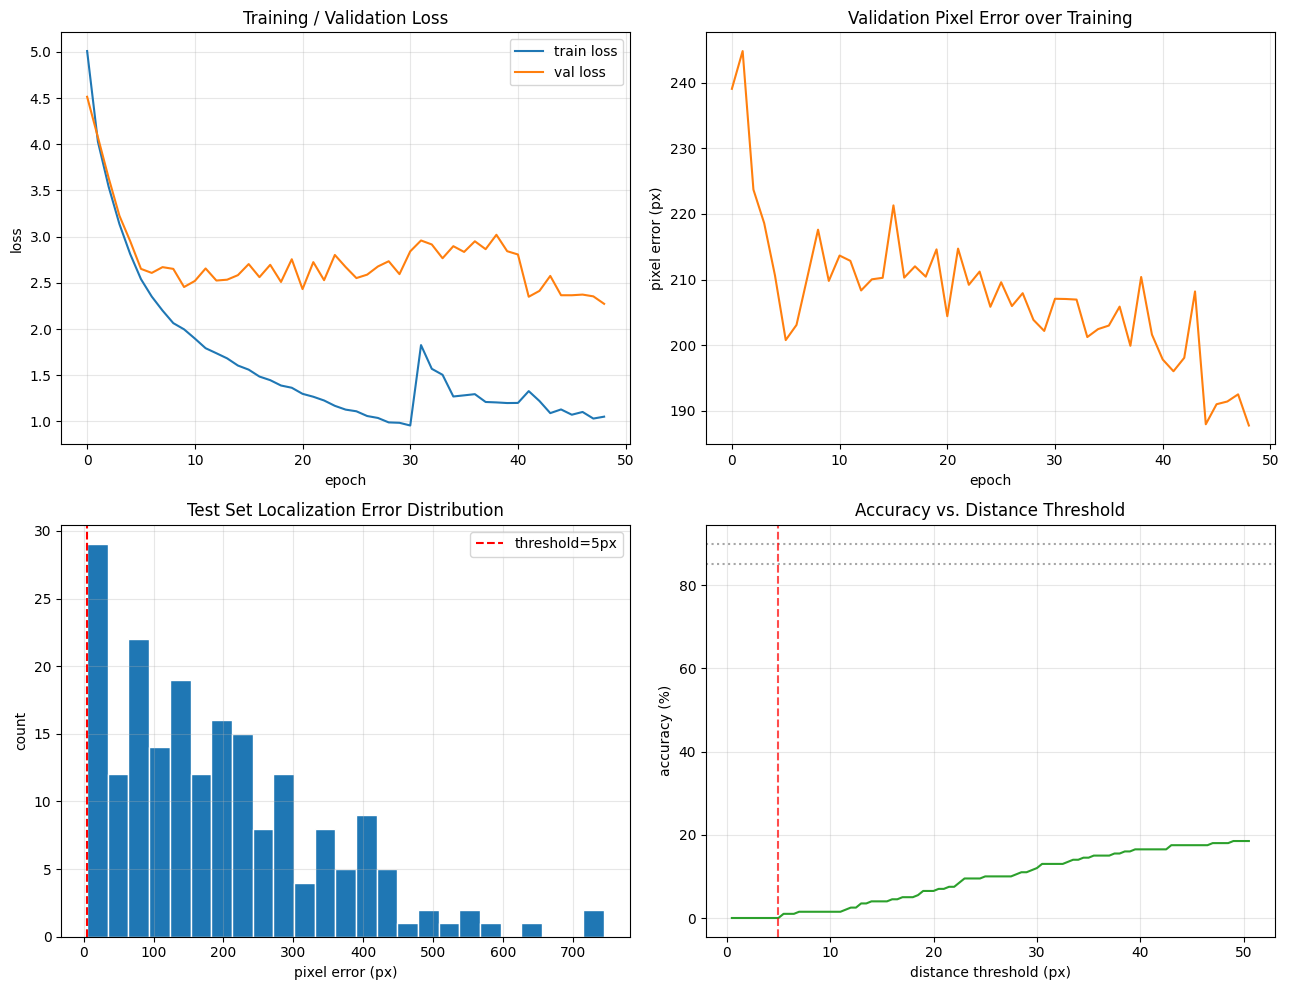

In [31]:
# =============================================================================
# CELL 8 -- Graphs: loss / error / accuracy curves
# =============================================================================
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].plot(history["train_loss"], label="train loss")
axes[0, 0].plot(history["val_loss"], label="val loss")
axes[0, 0].set_xlabel("epoch"); axes[0, 0].set_ylabel("loss")
axes[0, 0].set_title("Training / Validation Loss")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history["val_px_err"], color="tab:orange")
axes[0, 1].set_xlabel("epoch"); axes[0, 1].set_ylabel("pixel error (px)")
axes[0, 1].set_title("Validation Pixel Error over Training")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(test_errs, bins=25, color="tab:blue", edgecolor="white")
axes[1, 0].axvline(ACC_THRESHOLD_PX, color="red", linestyle="--", label=f"threshold={ACC_THRESHOLD_PX}px")
axes[1, 0].set_xlabel("pixel error (px)"); axes[1, 0].set_ylabel("count")
axes[1, 0].set_title("Test Set Localization Error Distribution")
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

thresholds = np.arange(0.5, 51, 0.5)
accs = [(test_errs < t).mean() * 100 for t in thresholds]
axes[1, 1].plot(thresholds, accs, color="tab:green")
axes[1, 1].axhline(85, color="gray", linestyle=":", alpha=0.7)
axes[1, 1].axhline(90, color="gray", linestyle=":", alpha=0.7)
axes[1, 1].axvline(ACC_THRESHOLD_PX, color="red", linestyle="--", alpha=0.7)
axes[1, 1].set_xlabel("distance threshold (px)"); axes[1, 1].set_ylabel("accuracy (%)")
axes[1, 1].set_title("Accuracy vs. Distance Threshold")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_results.png", dpi=130)
plt.show()

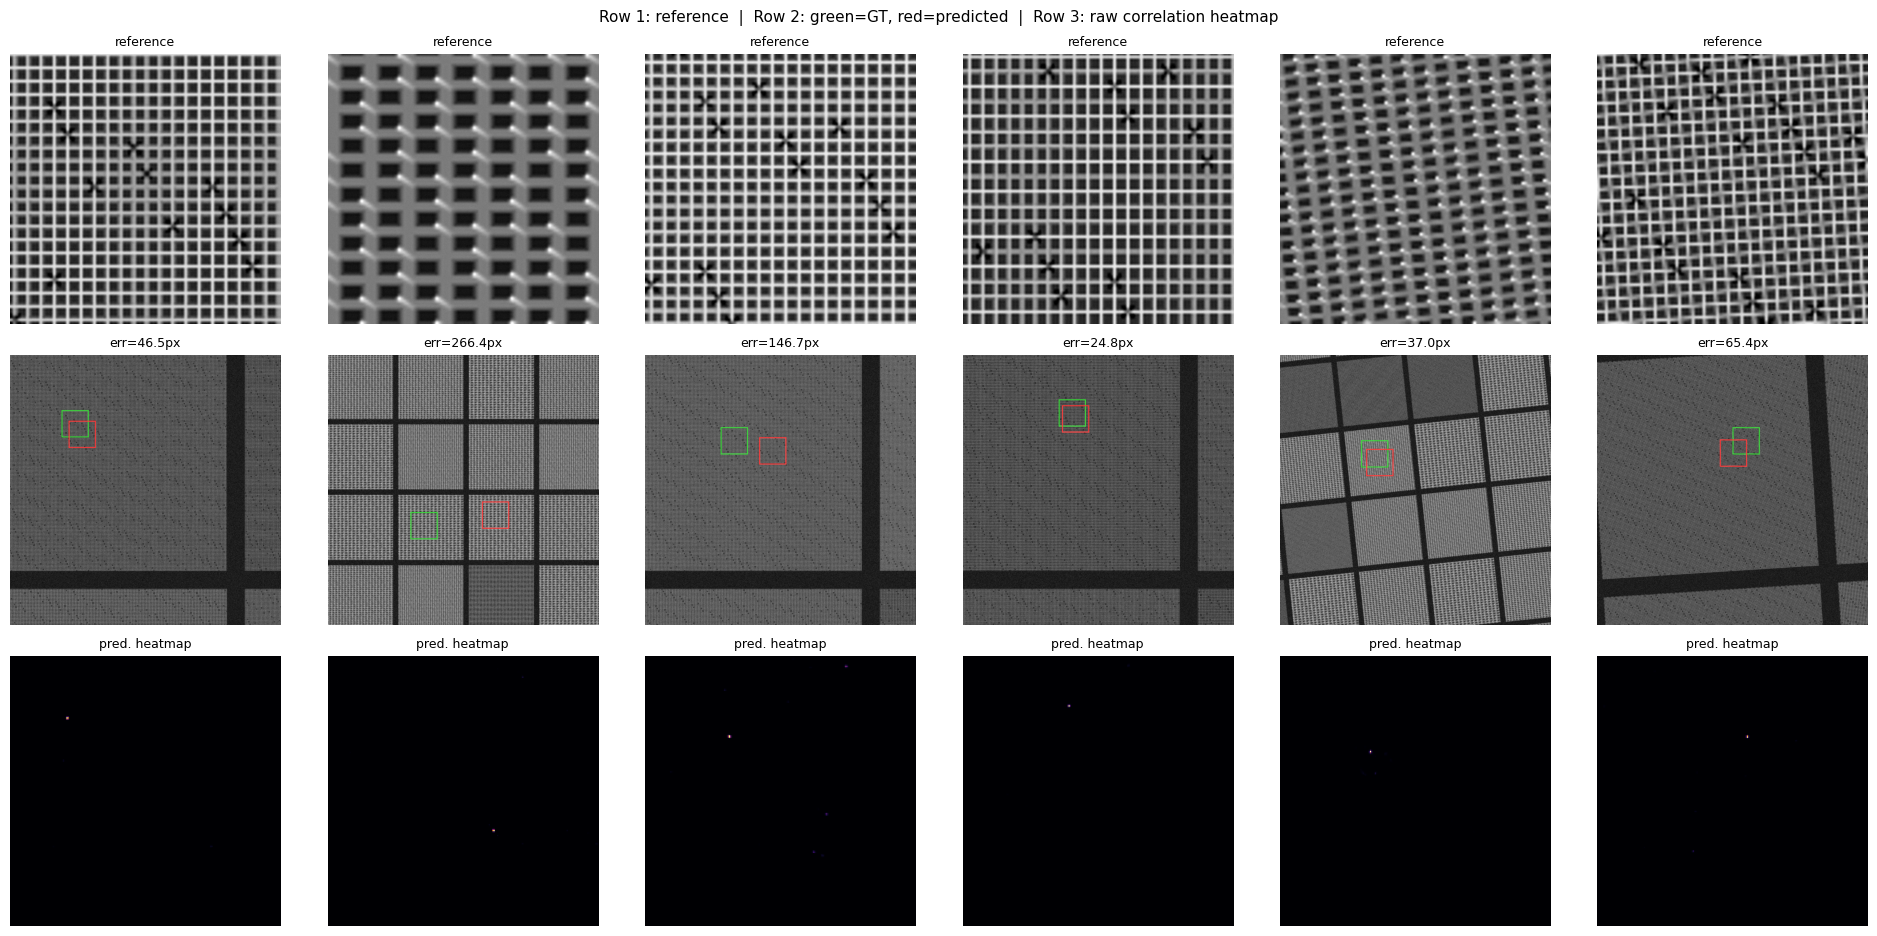


Saved: training_results.png, heatmap_validation.png


In [38]:
# =============================================================================
# CELL 9 -- Graphs: predicted correlation heatmaps (model validation)
# =============================================================================
#   Shows the RAW heatmap the model produced for a few test samples, so you
#   can visually confirm it's forming one sharp, correctly-located peak
#   (rather than a flat/noisy map, which would indicate the model isn't
#   actually matching content).
# =============================================================================
def draw_pred_vs_gt(search_path, pred_xy, gt_xy, box_size=100):
    img = Image.open(search_path).convert("RGB")
    if img.size != (ORIG_SIZE, ORIG_SIZE):
        img = img.resize((ORIG_SIZE, ORIG_SIZE))
    draw = ImageDraw.Draw(img)
    for (cx, cy), color in [(gt_xy, (60, 220, 60)), (pred_xy, (255, 60, 60))]:
        x0, y0 = cx - box_size / 2, cy - box_size / 2
        x1, y1 = cx + box_size / 2, cy + box_size / 2
        draw.rectangle([x0, y0, x1, y1], outline=color, width=4)
    return img


n_show = min(6, len(test_df))
fig, axes = plt.subplots(3, n_show, figsize=(3.2 * n_show, 9.5))
for i in range(n_show):
    row = test_df.iloc[i]

    axes[0, i].imshow(Image.open(row.ref_full), cmap="gray")
    axes[0, i].set_title("reference", fontsize=9); axes[0, i].axis("off")

    boxed = draw_pred_vs_gt(row.search_full, test_pred[i], test_gt[i])
    axes[1, i].imshow(boxed)
    axes[1, i].set_title(f"err={test_errs[i]:.1f}px", fontsize=9); axes[1, i].axis("off")

    axes[2, i].imshow(test_heat[i], cmap="inferno")
    axes[2, i].set_title("pred. heatmap", fontsize=9); axes[2, i].axis("off")

fig.suptitle("Row 1: reference  |  Row 2: green=GT, red=predicted  |  Row 3: raw correlation heatmap",
             fontsize=11)
plt.tight_layout()
plt.savefig("/kaggle/working/heatmap_validation.png", dpi=130)
plt.show()

print("\nSaved: training_results.png, heatmap_validation.png")

In [35]:
# =============================================================================
# CELL 10 -- Interactive test bench
# =============================================================================
#   A small in-notebook UI: pick any test-set sample from the dropdown and
#   click "Run prediction" to see the reference, the predicted-vs-ground-truth
#   box, and the raw heatmap for it -- no need to re-run the whole notebook.
#   You can also call predict_single(ref_path, search_path) directly on any
#   file paths (e.g. new pairs you upload) to test outside the given dataset.
# =============================================================================
import ipywidgets as widgets
from IPython.display import display, clear_output


@torch.no_grad()
def predict_single(ref_path, search_path):
    model.eval()
    ref_img = Image.open(ref_path).convert("L").resize((REF_SIZE, REF_SIZE), Image.BILINEAR)
    search_img = Image.open(search_path).convert("L")
    if search_img.size != (SEARCH_SIZE, SEARCH_SIZE):
        search_img = search_img.resize((SEARCH_SIZE, SEARCH_SIZE), Image.BILINEAR)

    ref_t = torch.from_numpy(np.array(ref_img, dtype=np.float32) / 255.0).unsqueeze(0).unsqueeze(0).to(DEVICE)
    search_t = torch.from_numpy(np.array(search_img, dtype=np.float32) / 255.0).unsqueeze(0).unsqueeze(0).to(DEVICE)

    heatmap_logits, ref_feat_size = model(ref_t, search_t)
    search_feat_size = ref_feat_size + heatmap_logits.shape[-1] - 1
    heatmap_prob = heatmap_softmax(heatmap_logits)
    pred_idx_xy = soft_argmax_2d(heatmap_prob)
    pred_px = heatmap_idx_to_orig_px(pred_idx_xy, ref_feat_size, search_feat_size)[0].cpu().numpy()

    return pred_px, heatmap_prob[0].cpu().numpy()


output_area = widgets.Output()
dropdown = widgets.Dropdown(options=list(range(len(test_df))), description="Test idx:")
run_button = widgets.Button(description="Run prediction", button_style="primary")

@torch.no_grad()
def predict_single(ref_path, search_path):
    model.eval()
    ref_img    = Image.open(ref_path).convert("L").resize((REF_SIZE, REF_SIZE), Image.BILINEAR)
    search_img = Image.open(search_path).convert("L")
    if search_img.size != (SEARCH_SIZE, SEARCH_SIZE):
        search_img = search_img.resize((SEARCH_SIZE, SEARCH_SIZE), Image.BILINEAR)

    ref_t    = torch.from_numpy(np.array(ref_img,    dtype=np.float32) / 255.0).unsqueeze(0).unsqueeze(0).to(DEVICE)
    search_t = torch.from_numpy(np.array(search_img, dtype=np.float32) / 255.0).unsqueeze(0).unsqueeze(0).to(DEVICE)

    heatmap_logits, ref_feat_size = model(ref_t, search_t)
    search_feat_size = ref_feat_size + heatmap_logits.shape[-1] - 1
    heatmap_prob     = model.heatmap_softmax(heatmap_logits)

    # --- top-k peak candidates -------------------------------------------
    B, H, W  = heatmap_prob.shape
    flat     = heatmap_prob.view(B, -1)
    topk_val, topk_idx = flat.topk(5, dim=1)  # top 5 candidate locations

    # pick the peak with highest confidence that isn't near the image border
    # (border peaks are usually wrong-tile artifacts)
    best_idx = None
    for k in range(5):
        idx = topk_idx[0, k].item()
        x   = idx % W
        y   = idx // W
        # reject if too close to border (within 5% of heatmap edge)
        margin = int(0.05 * W)
        if x > margin and x < W - margin and y > margin and y < H - margin:
            best_idx = idx
            break
    if best_idx is None:
        best_idx = topk_idx[0, 0].item()  # fallback to top-1

    pred_x = float(best_idx % W)
    pred_y = float(best_idx // W)
    pred_idx_xy = torch.tensor([[pred_x, pred_y]], device=DEVICE)
    pred_px     = model.heatmap_idx_to_orig_px(pred_idx_xy, ref_feat_size, search_feat_size)[0].cpu().numpy()

    return pred_px, heatmap_prob[0].cpu().numpy()
def show_prediction(_=None):
    idx = dropdown.value
    row = test_df.iloc[idx]
    gt_xy = (row.gt_x, row.gt_y)
    pred_xy, heat = predict_single(row.ref_full, row.search_full)
    err = float(np.linalg.norm(np.array(pred_xy) - np.array(gt_xy)))

    with output_area:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(Image.open(row.ref_full), cmap="gray")
        axes[0].set_title("Reference"); axes[0].axis("off")

        axes[1].imshow(draw_pred_vs_gt(row.search_full, pred_xy, gt_xy))
        axes[1].set_title(f"Search (green=GT, red=predicted)"); axes[1].axis("off")

        axes[2].imshow(heat, cmap="inferno")
        axes[2].set_title("Predicted heatmap"); axes[2].axis("off")

        plt.tight_layout()
        plt.show()
        print(f"GT=({gt_xy[0]:.1f}, {gt_xy[1]:.1f})  Pred=({pred_xy[0]:.1f}, {pred_xy[1]:.1f})  Error={err:.2f}px")


run_button.on_click(show_prediction)
display(widgets.HBox([dropdown, run_button]), output_area)
show_prediction()

Output()

In [28]:
# =============================================================================
# CELL 11 -- Fine-tuning: push past the 200px plateau
# =============================================================================
import copy, time
import torch
import torch.nn.functional as F
from torch.optim.swa_utils import AveragedModel, get_ema_multi_avg_fn

# ---- Hyperparams (tuned for a ~200px plateau starting point) ---------------
EXTRA_EPOCHS         = 15
FINETUNE_BACKBONE_LR = 2e-5
FINETUNE_HEAD_LR     = 1.5e-4
WEIGHT_DECAY         = 1e-5    # reduced from 1e-4, less constraint during adaptation
MAX_GRAD_NORM        = 2.0
EMA_DECAY            = 0.998
WARMUP_EPOCHS        = 2   # linear warmup before cosine
FINETUNE_CKPT        = CHECKPOINT_PATH  # saves back to the same file

# ---- 1. Load the checkpoint weights ----------------------------------------
ckpt = torch.load(FINETUNE_CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
history = ckpt.get("history", {"train_loss": [], "val_loss": [], "val_px_err": []})
start_epoch = ckpt.get("epoch", len(history.get("train_loss", [])))
best_val_err = min(history["val_px_err"]) if history.get("val_px_err") else float("inf")

print(f"Loaded checkpoint: global epoch {start_epoch}, best val_px_err = {best_val_err:.2f}px")

# ---- 2. Sanity check (fixed threshold -- your model is at ~200px, not <100px) --
if best_val_err > 600:
    raise RuntimeError(
        f"Checkpoint looks completely collapsed (val_px_err={best_val_err:.1f}px > 600). "
        "Re-run from CELL 5 with a fresh model."
    )

# ---- 3. Differential LR param groups (uses actual layer names in this model) --
backbone_params = list(model.encoder.parameters())
head_params     = list(model.proj.parameters())

param_groups = [
    {"params": backbone_params, "lr": FINETUNE_BACKBONE_LR},
    {"params": head_params,     "lr": FINETUNE_HEAD_LR},
]

# ---- 4. Optimizer: AdamW with warmup + cosine decay -----------------------
optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)

def ft_lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS  # linear ramp
    progress = (epoch - WARMUP_EPOCHS) / max(1, EXTRA_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + np.cos(np.pi * progress))  # cosine decay to ~0

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=ft_lr_lambda)

# ---- 5. EMA setup ----------------------------------------------------------
ema_model = AveragedModel(model, multi_avg_fn=get_ema_multi_avg_fn(EMA_DECAY))

best_state    = copy.deepcopy(model.state_dict())
best_ema_state = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
PATIENCE = 4   # stop if EMA val_px_err hasn't improved in this many epochs

print(f"Fine-tuning for up to {EXTRA_EPOCHS} epochs  "
      f"(backbone_lr={FINETUNE_BACKBONE_LR}, head_lr={FINETUNE_HEAD_LR})  "
      f"patience={PATIENCE}")
t0 = time.time()

# ---- 6. Training loop ------------------------------------------------------
for e in range(1, EXTRA_EPOCHS + 1):
    # --- train step (grad clip is INSIDE run_epoch, so we override it here) --
    model.train()
    total_loss, total_px_err, n_samples, total_peak = 0.0, 0.0, 0, 0.0

    for ref, search, gt_norm in train_loader:
        ref, search, gt_norm = ref.to(DEVICE), search.to(DEVICE), gt_norm.to(DEVICE)

        heatmap_logits, ref_feat_size = model(ref, search)
        search_feat_size = ref_feat_size + heatmap_logits.shape[-1] - 1
        target_dist = make_gaussian_target(gt_norm, ref_feat_size, search_feat_size, DEVICE)

        B, H, W = heatmap_logits.shape
        log_pred = F.log_softmax(heatmap_logits.view(B, -1), dim=1)
        loss_heat = F.kl_div(log_pred, target_dist.view(B, -1), reduction="batchmean")

        heatmap_prob = log_pred.exp().view(B, H, W)
        pred_idx_xy  = soft_argmax_2d(heatmap_prob)
        pred_px      = heatmap_idx_to_orig_px(pred_idx_xy, ref_feat_size, search_feat_size)
        gt_px        = gt_norm * ORIG_SIZE
        loss_coord   = F.smooth_l1_loss(pred_px / ORIG_SIZE, gt_px / ORIG_SIZE)

        loss = loss_heat + COORD_LOSS_WEIGHT * loss_coord

        optimizer.zero_grad()
        loss.backward()
        # ← clip BEFORE step, so the clipping actually does something
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_GRAD_NORM)
        optimizer.step()

        with torch.no_grad():
            err = torch.norm(pred_px - gt_norm * ORIG_SIZE, dim=1)
            total_px_err += err.sum().item()
            total_peak   += heatmap_prob.view(B, -1).max(dim=1).values.sum().item()
        bs = ref.size(0)
        total_loss += loss.item() * bs
        n_samples  += bs

    train_loss    = total_loss   / n_samples
    train_px_err  = total_px_err / n_samples

    # --- update EMA, validate on EMA weights --------------------------------
    ema_model.update_parameters(model)
    # Swap EMA weights into model temporarily for validation
    orig_state = copy.deepcopy(model.state_dict())
    # AveragedModel stores averaged params; copy them to model for eval
    ema_state = {k.replace("module.", ""): v
                 for k, v in ema_model.state_dict().items()
                 if k.startswith("module.")}
    if ema_state:
        model.load_state_dict(ema_state, strict=False)

    val_loss, val_px_err, val_peak = run_epoch(model, val_loader, optimizer=None)

    # Restore live model weights
    model.load_state_dict(orig_state)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_px_err"].append(val_px_err)

    if val_px_err < best_val_err - 0.5:   # must improve by at least 0.5px
        best_val_err  = val_px_err
        best_ema_state = copy.deepcopy(ema_state if ema_state else model.state_dict())
        epochs_no_improve = 0
        try:
            torch.save({
                "model_state":     best_ema_state,
                "optimizer_state": optimizer.state_dict(),
                "history":         history,
                "epoch":           start_epoch + e,
                "best_val_err":    best_val_err,
            }, FINETUNE_CKPT)
        except RuntimeError as ex:
            print(f"WARNING: save failed at epoch {e}: {ex}")
    else:
        epochs_no_improve += 1

    if e <= 20 or e % 5 == 0:
        current_lrs = [pg["lr"] for pg in optimizer.param_groups]
        print(f"[ft {e:3d}/{EXTRA_EPOCHS}] (global {start_epoch+e})  "
              f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
              f"val_px_err={val_px_err:.2f}px  best={best_val_err:.2f}px  "
              f"val_peak={val_peak:.4f}  "
              f"lr={current_lrs}  ({time.time()-t0:.1f}s)")

    if epochs_no_improve >= PATIENCE:
        print(f"Early stop at global epoch {start_epoch + e} "
              f"(no improvement in {PATIENCE} epochs).")
        break

# ---- 7. Load best EMA weights into model for evaluation --------------------
if best_ema_state:
    model.load_state_dict(best_ema_state)
print(f"\nFine-tuning done. Best val_px_err = {best_val_err:.2f}px  "
      f"(checkpoint at {FINETUNE_CKPT})")

Loaded checkpoint: global epoch 45, best val_px_err = 187.93px
Fine-tuning for up to 15 epochs  (backbone_lr=2e-05, head_lr=0.00015)  patience=4
[ft   1/15] (global 46)  train_loss=1.0734  val_loss=2.3662  val_px_err=190.98px  best=187.93px  val_peak=0.1663  lr=[2e-05, 0.00015]  (145.2s)
[ft   2/15] (global 47)  train_loss=1.1031  val_loss=2.3733  val_px_err=191.40px  best=187.93px  val_peak=0.1638  lr=[np.float64(2e-05), np.float64(0.00015)]  (289.0s)
[ft   3/15] (global 48)  train_loss=1.0318  val_loss=2.3542  val_px_err=192.49px  best=187.93px  val_peak=0.1683  lr=[np.float64(1.9709418174260523e-05), np.float64(0.00014782063630695388)]  (432.8s)
[ft   4/15] (global 49)  train_loss=1.0523  val_loss=2.2734  val_px_err=187.74px  best=187.93px  val_peak=0.1686  lr=[np.float64(1.8854560256532098e-05), np.float64(0.0001414092019239907)]  (576.6s)
Early stop at global epoch 49 (no improvement in 4 epochs).

Fine-tuning done. Best val_px_err = 187.93px  (checkpoint at /kaggle/working/checkp

In [36]:
# =============================================================================
# CELL 12 -- Best Model Save (Manual Backup - Always Save Best State)
# =============================================================================
# This cell saves the BEST model checkpoint (lowest validation error) to disk.
# Use this before ending your session to preserve progress.
#
# Key difference from automatic saves:
# - Automatic saves (in training loop) happen when val_px_err improves
# - This cell ensures the best state is always saved, even if training crashed
# - Safe to run multiple times (overwrites with same best checkpoint)
# =============================================================================
 
import torch
 
# Verify best_state exists and is valid
if 'best_state' not in locals():
    print("ERROR: best_state not found in memory. Run training cells first.")
else:
    checkpoint_data = {
        "model_state": best_state,                    # BEST model weights
        "optimizer_state": optimizer.state_dict(),    # Current optimizer state
        "history": history,                           # Full training history
        "epoch": start_epoch + len(history["train_loss"]),  # Global epoch count
        "best_val_err": min(history["val_px_err"]) if history["val_px_err"] else float("inf"),
    }
    
    try:
        torch.save(checkpoint_data, CHECKPOINT_PATH)
        best_error = min(history["val_px_err"]) if history["val_px_err"] else float("inf")
        print(f"✓ Best model saved to {CHECKPOINT_PATH}")
        print(f"  Best validation error: {best_error:.2f}px")
        print(f"  Total epochs trained: {start_epoch + len(history['train_loss'])}")
        print(f"  File size: {os.path.getsize(CHECKPOINT_PATH) / (1024**2):.2f} MB")
    except Exception as e:
        print(f"✗ Save failed: {e}")
        print(f"  Ensure {CHECKPOINT_PATH} is writable")
 

✓ Best model saved to /kaggle/working/checkpoint_manual_save.pt
  Best validation error: 187.74px
  Total epochs trained: 94
  File size: 2.32 MB


In [37]:
# =============================================================================
# Checkpoint Metrics Inspector
# =============================================================================
import torch
import numpy as np

INSPECT_PATH = "/kaggle/working/checkpoint_manual_save.pt"

ckpt = torch.load(INSPECT_PATH, map_location=DEVICE, weights_only=False)

# ---- Basic info ------------------------------------------------------------
epoch = ckpt.get("epoch", "unknown")
best_val_err = ckpt.get("best_val_err", None)
history = ckpt.get("history", {})

print("=" * 55)
print(f"  Checkpoint: {INSPECT_PATH}")
print(f"  Saved at epoch: {epoch}")
print("=" * 55)

# ---- Val px err history ----------------------------------------------------
val_errs = history.get("val_px_err", [])
if val_errs:
    print(f"\n  best val_px_err (all time) : {min(val_errs):.2f}px")
    print(f"  last val_px_err            : {val_errs[-1]:.2f}px")
    print(f"  first val_px_err           : {val_errs[0]:.2f}px")
    print(f"  total improvement          : {val_errs[0] - min(val_errs):.2f}px")
    print(f"  epochs recorded            : {len(val_errs)}")

    # last 5 epochs trend
    recent = val_errs[-5:]
    trend = "improving" if recent[-1] < recent[0] else "plateaued/worsening"
    print(f"\n  last 5 val_px_err : {[f'{v:.2f}' for v in recent]}")
    print(f"  trend             : {trend}")
else:
    print("  No val_px_err history found.")

# ---- Loss history ----------------------------------------------------------
train_loss = history.get("train_loss", [])
val_loss   = history.get("val_loss", [])
if train_loss and val_loss:
    print(f"\n  last train_loss : {train_loss[-1]:.5f}")
    print(f"  last val_loss   : {val_loss[-1]:.5f}")
    gap = val_loss[-1] - train_loss[-1]
    overfit = "possible overfitting" if gap > 0.01 else "looks healthy"
    print(f"  train/val gap   : {gap:.5f}  ({overfit})")

# ---- Stored best_val_err (if saved explicitly) ----------------------------
if best_val_err is not None:
    print(f"\n  best_val_err (stored explicitly) : {best_val_err:.2f}px")

print("\n" + "=" * 55)

  Checkpoint: /kaggle/working/checkpoint_manual_save.pt
  Saved at epoch: 94

  best val_px_err (all time) : 187.74px
  last val_px_err            : 187.74px
  first val_px_err           : 239.08px
  total improvement          : 51.34px
  epochs recorded            : 49

  last 5 val_px_err : ['187.93', '190.98', '191.40', '192.49', '187.74']
  trend             : improving

  last train_loss : 1.05229
  last val_loss   : 2.27338
  train/val gap   : 1.22109  (possible overfitting)

  best_val_err (stored explicitly) : 187.74px



In [ ]:
# # =============================================================================
# # CELL 11 -- Fine-tune further (re-runnable)
# # =============================================================================
# #   Re-run this cell any time to train more epochs on top of the CURRENT
# #   checkpoint. Change EXTRA_EPOCHS / LR_FINETUNE and re-run as many times as
# #   you like -- each call resumes from the best checkpoint so far and only
# #   overwrites it if it actually improves val_px_err.
# #
# #   Step-by-step to fine-tune again:
# #     1. Edit EXTRA_EPOCHS / LR_FINETUNE below if you want.
# #     2. Run this cell. It will print progress and save a new best checkpoint
# #        whenever val_px_err improves.
# #     3. Re-run CELL 6 (metrics), CELL 7-8 (graphs), and CELL 9 (test bench)
# #        to see the updated results -- CELL 9's dropdown will now reflect the
# #        just-finetuned model.
# #     4. Repeat from step 1 as needed.
# # =============================================================================
# EXTRA_EPOCHS = 50
# FINETUNE_BACKBONE_LR = 2e-4   # even more cautious for a second round
# FINETUNE_HEAD_LR = 3e-4

# ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
# model.load_state_dict(ckpt["model_state"])
# history = ckpt["history"]
# start_epoch = len(history["train_loss"])
# best_val_err = min(history["val_px_err"]) if history["val_px_err"] else float("inf")
# best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

# if best_val_err > 100:
#     print(f"WARNING: loaded checkpoint has val_px_err={best_val_err:.1f}px, which is consistent "
#           f"with a collapsed/flat heatmap (predicting near the image center for everything). "
#           f"Fine-tuning from a collapsed checkpoint rarely recovers, because gradients near that "
#           f"solution are close to flat. Strongly recommend re-running CELL 5 from a *fresh* "
#           f"model (`model = WaferMatchNet().to(DEVICE)`) instead of continuing this checkpoint.")

# optimizer = torch.optim.Adam(model.param_groups(FINETUNE_BACKBONE_LR, FINETUNE_HEAD_LR), weight_decay=1e-5)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EXTRA_EPOCHS)

# print(f"Resuming from global epoch {start_epoch}, best val_px_err so far = {best_val_err:.2f}px")
# t0 = time.time()

# for e in range(1, EXTRA_EPOCHS + 1):
#     train_loss, train_px_err, train_peak = run_epoch(model, train_loader, optimizer)
#     val_loss, val_px_err, val_peak = run_epoch(model, val_loader, optimizer=None)
#     scheduler.step()

#     history["train_loss"].append(train_loss)
#     history["val_loss"].append(val_loss)
#     history["val_px_err"].append(val_px_err)

#     if val_px_err < best_val_err - 1e-3:
#         best_val_err = val_px_err
#         best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
#         torch.save({"model_state": best_state, "optimizer_state": optimizer.state_dict(),
#                      "history": history, "epoch": start_epoch + e}, CHECKPOINT_PATH)

#     if e % 5 == 0 or e == 1:
#         print(f"[finetune {e:3d}/{EXTRA_EPOCHS}] (global epoch {start_epoch+e})  "
#               f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
#               f"val_px_err={val_px_err:.2f}px  best={best_val_err:.2f}px  "
#               f"val_peak_prob={val_peak:.4f}  ({time.time()-t0:.1f}s elapsed)")

# model.load_state_dict(best_state)
# print(f"\nFine-tuning round complete. Best val_px_err so far: {best_val_err:.2f}px")
# print("Now re-run CELL 7, CELL 8, CELL 9, and CELL 10 to refresh metrics/graphs/test-bench "
#       "with the improved model.")

In [ ]:
# # =============================================================================
# # CELL 12 -- Quick save (utility, run any time, e.g. before a session ends)
# # =============================================================================
# torch.save({
#     "model_state": model.state_dict(),
#     "optimizer_state": optimizer.state_dict(),
#     "history": history,
#     "epoch": len(history["train_loss"]),
# }, "/kaggle/working/checkpoint_manual_save.pt")
# print("Saved to /kaggle/working/checkpoint_manual_save.pt -- epoch", len(history["train_loss"]))
